<a href="https://colab.research.google.com/github/Clestialcosmos/Data_Visualisation/blob/main/plotly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/plotly_dv_lab_3.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   200 non-null    object 
 1   Region                 200 non-null    object 
 2   Product_Category       200 non-null    object 
 3   Marketing_Spend        200 non-null    float64
 4   Revenue                200 non-null    float64
 5   Expenses               200 non-null    float64
 6   Profit                 200 non-null    float64
 7   Active_Users           200 non-null    int64  
 8   New_Signups            200 non-null    int64  
 9   Customer_Satisfaction  200 non-null    float64
 10  Conversion_Rate        200 non-null    float64
 11  Discount_Applied       200 non-null    object 
 12  Month                  200 non-null    object 
dtypes: float64(6), int64(2), object(5)
memory usage: 20.4+ KB


In [4]:
df.describe()

,Marketing_Spend,Revenue,Expenses,Profit,Active_Users,New_Signups,Customer_Satisfaction,Conversion_Rate
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,4530.625900,19311.110500,7227.553450,12083.556250,8415.525000,731.905000,4.271500,0.086504
std,2051.008245,10045.615242,2212.527407,8331.343113,3600.474998,470.611263,0.454005,0.038147
min,1035.430000,3520.050000,2907.600000,-715.710000,2054.000000,41.000000,3.500000,0.020000
25%,2830.240000,11258.940000,5389.762500,5186.877500,5451.750000,375.750000,3.847500,0.055250
50%,4791.480000,18440.625000,7217.180000,10814.325000,7980.500000,622.000000,4.315000,0.087700
75%,6195.395000,26214.057500,8927.490000,17940.515000,11423.500000,1036.000000,4.660000,0.116975
max,7933.540000,45705.990000,11896.670000,35723.290000,14997.000000,2120.000000,4.990000,0.149900


In [5]:
df.isnull().sum()

,0
Date,0
Region,0
Product_Category,0
Marketing_Spend,0
Revenue,0
Expenses,0
Profit,0
Active_Users,0
New_Signups,0
Customer_Satisfaction,0


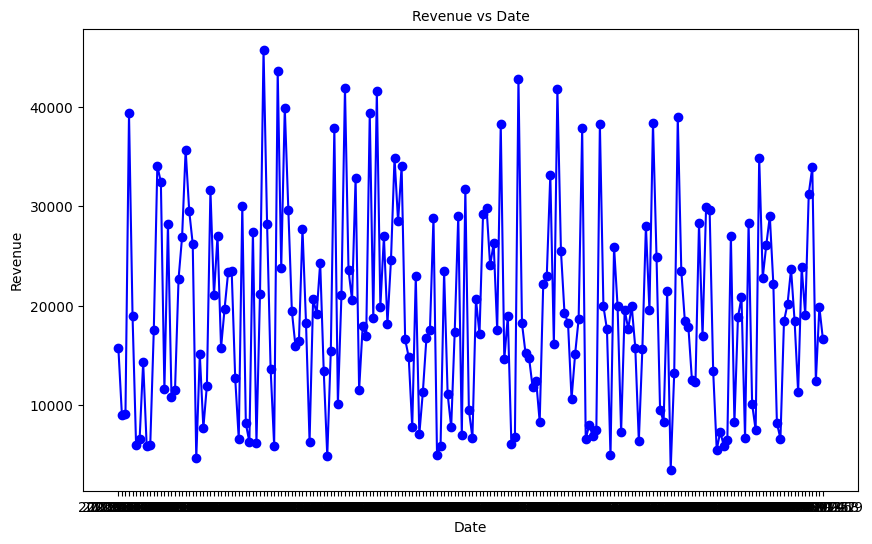

In [6]:
plt.figure(figsize=(10,6))
plt.plot(df["Date"],df["Revenue"],marker="o",color="Blue")
plt.xlabel("Date",fontsize = 10)
plt.ylabel("Revenue",fontsize = 10)
plt.title("Revenue vs Date",fontsize = 10)
plt.show()

Text(0.5, 1.0, 'Revenue vs Region')

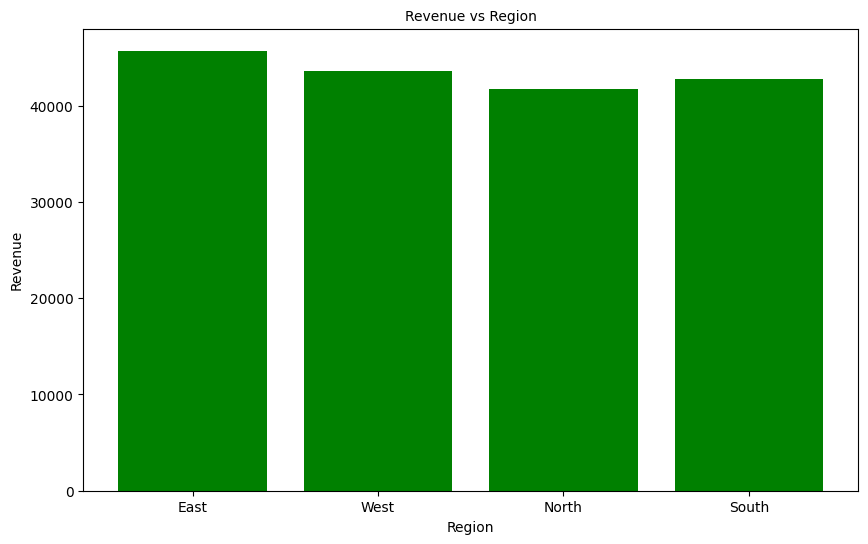

In [7]:
plt.figure(figsize=(10,6))
plt.bar(df["Region"],df['Revenue'],color="Green")
plt.xlabel("Region",fontsize = 10)
plt.ylabel("Revenue",fontsize = 10)
plt.title("Revenue vs Region",fontsize = 10)

Text(0.5, 1.0, 'Revenue vs Marketing_Spend')

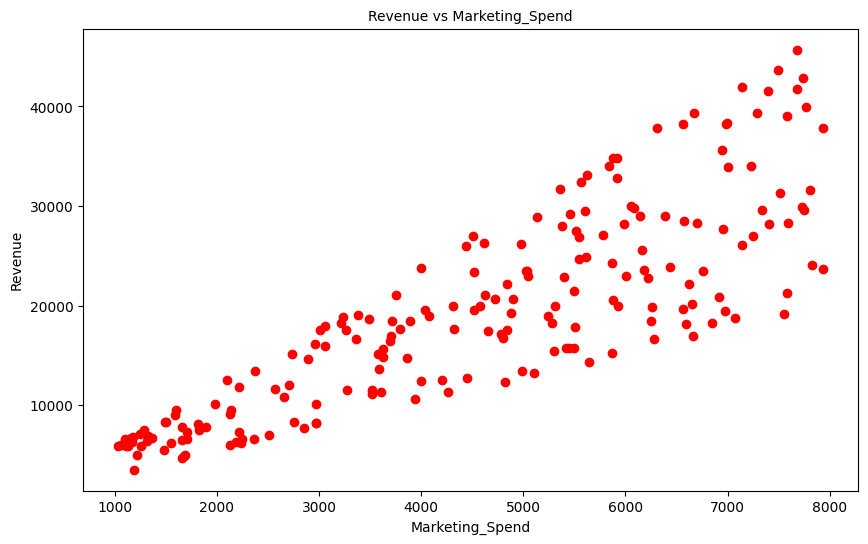

In [8]:
plt.figure(figsize=(10,6))
plt.scatter(df["Marketing_Spend"],df["Revenue"],color="Red")
plt.xlabel("Marketing_Spend",fontsize = 10)
plt.ylabel("Revenue",fontsize = 10)
plt.title("Revenue vs Marketing_Spend",fontsize = 10)

Text(0.5, 1.0, 'Product_Category')

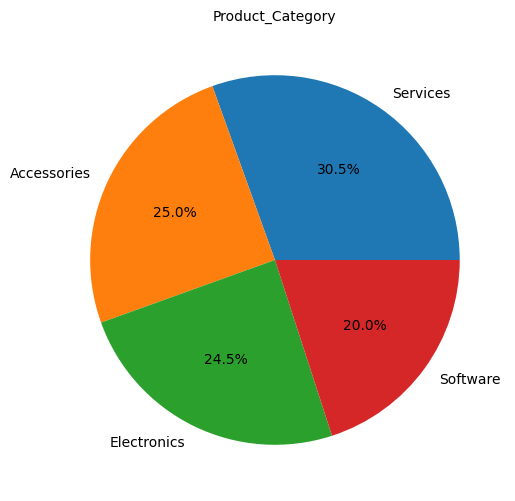

In [9]:
plt.figure(figsize=(10,6))
procat = df['Product_Category'].value_counts()
plt.pie(procat,labels=procat.index,autopct='%1.1f%%')
plt.title("Product_Category",fontsize = 10)

Text(0.5, 1.0, 'Customer_Satisfaction')

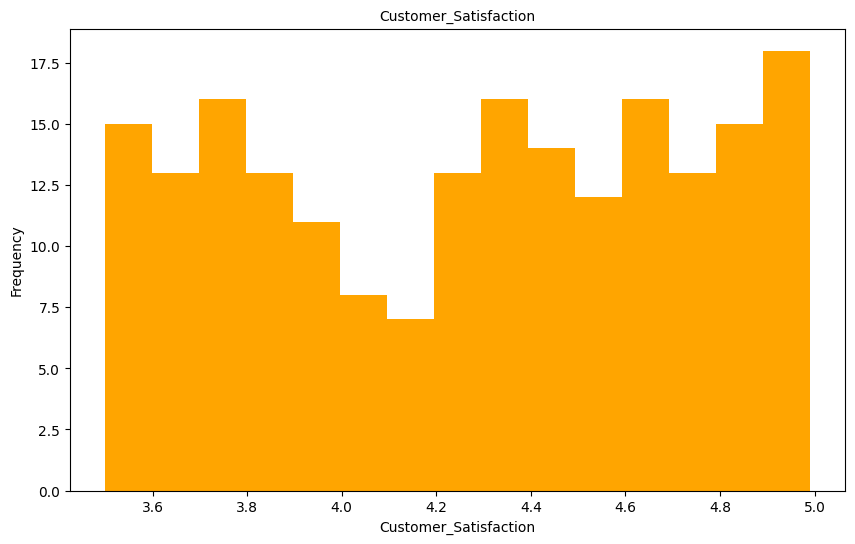

In [10]:
plt.figure(figsize=(10,6))
plt.hist(df['Customer_Satisfaction'],bins=15,color="Orange")
plt.xlabel("Customer_Satisfaction",fontsize = 10)
plt.ylabel("Frequency",fontsize = 10)
plt.title("Customer_Satisfaction",fontsize = 10)

Text(0.5, 0, 'Region')

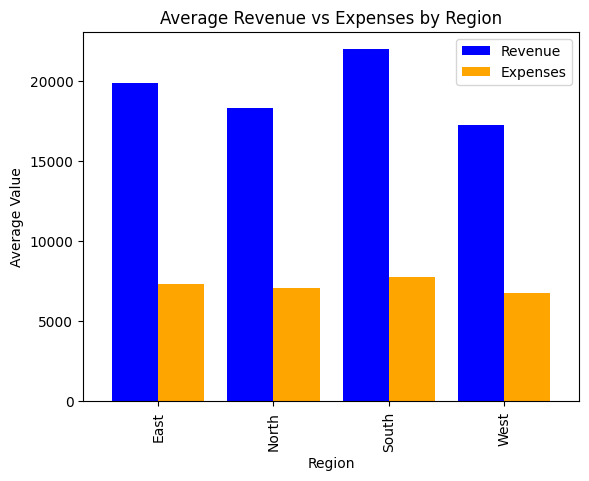

In [16]:
avg = df.groupby('Region')[['Revenue','Expenses']].mean()
avg.plot(kind='bar', width=0.8, color=['blue', 'orange'])
plt.title("Average Revenue vs Expenses by Region")
plt.ylabel("Average Value")
plt.xlabel("Region")

<Figure size 800x600 with 0 Axes>

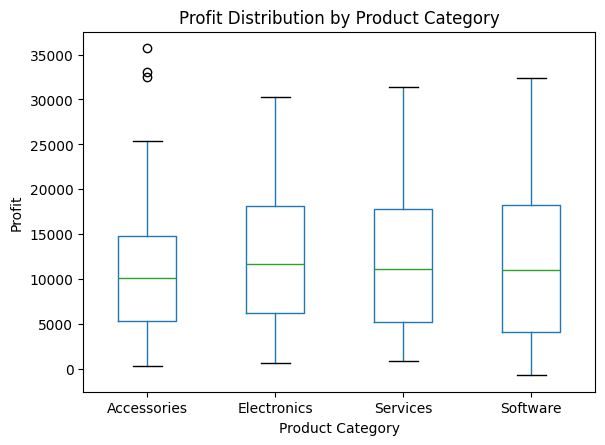

In [19]:
plt.figure(figsize=(8,6))
df.boxplot(column="Profit", by="Product_Category", grid=False)
plt.title("Profit Distribution by Product Category")
plt.suptitle("")
plt.xlabel("Product Category")
plt.ylabel("Profit")
plt.show()

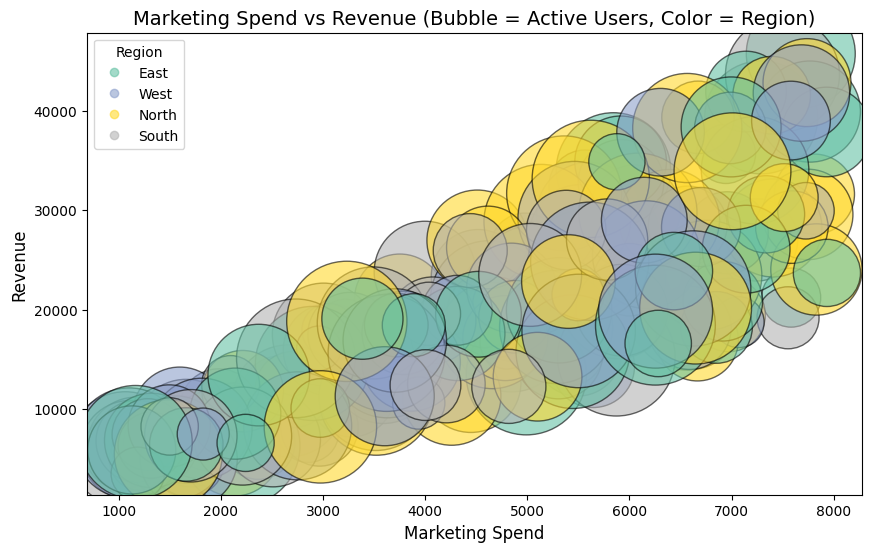

In [20]:
# Bubble chart: Marketing_Spend vs Revenue
plt.figure(figsize=(10,6))
scatter = plt.scatter(
    df['Marketing_Spend'],
    df['Revenue'],
    s=df['Active_Users']*0.5,   # Bubble size scaled by Active_Users
    c=df['Region'].astype('category').cat.codes,  # Color by Region
    cmap='Set2',
    alpha=0.6,
    edgecolor='black'
)

# Labels and title
plt.title("Marketing Spend vs Revenue (Bubble = Active Users, Color = Region)", fontsize=14)
plt.xlabel("Marketing Spend", fontsize=12)
plt.ylabel("Revenue", fontsize=12)

# Legend for regions
handles, labels = scatter.legend_elements(prop="colors")
region_labels = df['Region'].unique()
plt.legend(handles, region_labels, title="Region")

plt.show()


Text(0, 0.5, 'Values')

<Figure size 2000x1000 with 0 Axes>

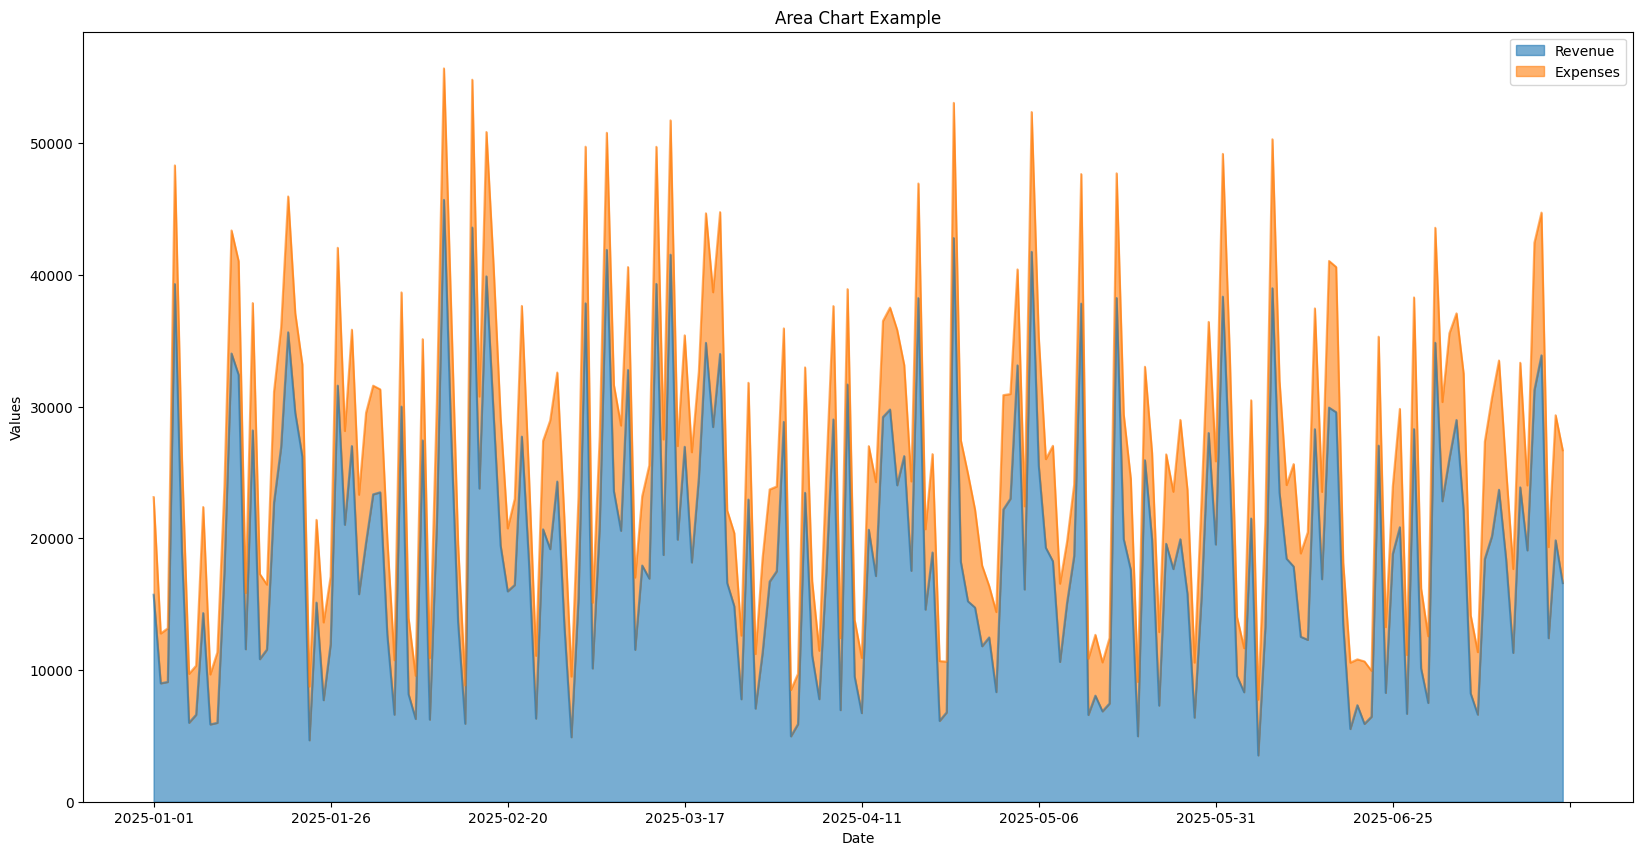

In [26]:
df.plot(
    x = 'Date',
    y = ['Revenue','Expenses'],
    kind = 'area',
    alpha = 0.6,
    figsize=(20,10)
)
plt.title("Area Chart Example")
plt.xlabel("Date")
plt.ylabel("Values")

/tmp/ipykernel_5093/790163757.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x = 'Region',y = 'Conversion_Rate',data = df,palette='Set1')


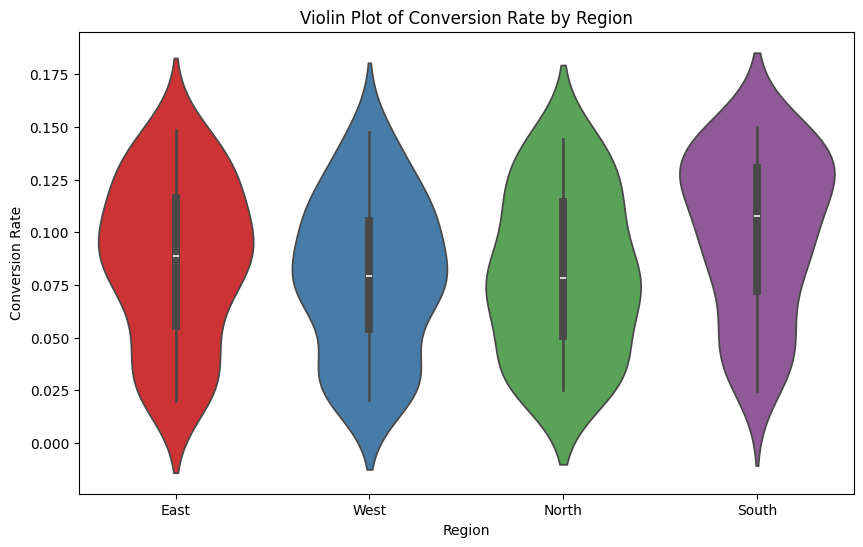

In [36]:
plt.figure(figsize=(10, 6))
sns.violinplot(x = 'Region',y = 'Conversion_Rate',data = df,palette='Set1')
plt.title("Violin Plot of Conversion Rate by Region")
plt.xlabel("Region")
plt.ylabel("Conversion Rate")
plt.show()

In [37]:
import plotly.express as px

In [39]:
agg_data = df.groupby(['Region', 'Product_Category'])['Revenue'].sum().reset_index()
fig = px.sunburst(
    agg_data,
    path=['Region', 'Product_Category'],  # hierarchy levels
    values='Revenue',                     # segment sizes
    color='Revenue',                      # optional: color by revenue
    color_continuous_scale='RdYlGn',      # red-yellow-green scale
)
fig.update_layout(title="Revenue Breakdown by Region and Product Category")
fig.show()

In [40]:
from mpl_toolkits.mplot3d import Axes3D

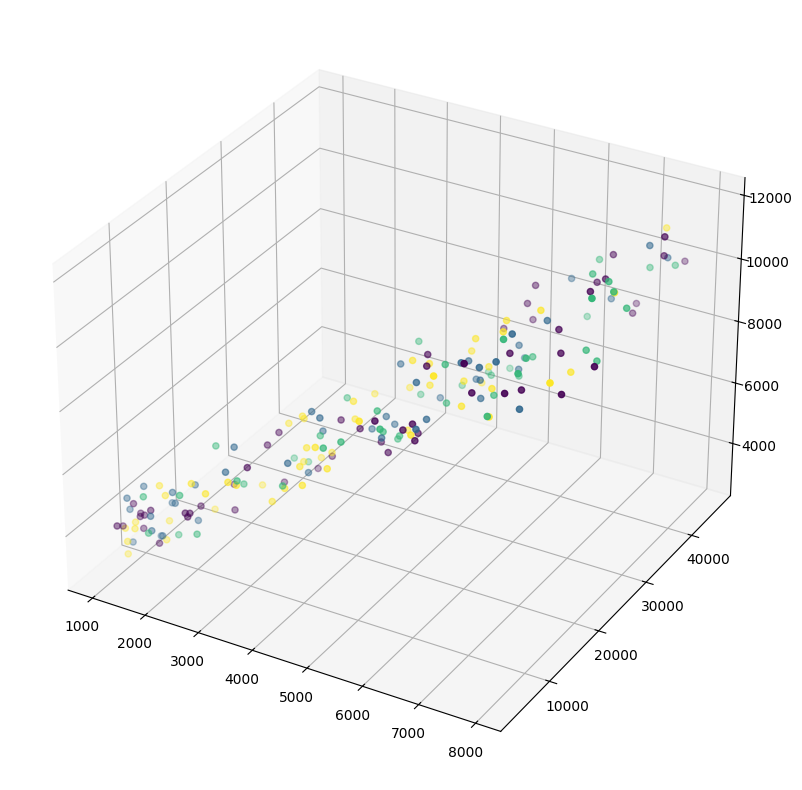

In [41]:
ax = plt.figure(figsize=(10,10)).add_subplot(111,projection='3d')
ax.scatter(df['Marketing_Spend'],df['Revenue'],df['Expenses'],c=df['Region'].astype('category').cat.codes)
plt.show()

In [42]:
import plotly.express as px

fig13 = px.density_heatmap(
    df,
    x="Active_Users",
    y="New_Signups",
    nbinsx=20,
    nbinsy=20,
    color_continuous_scale="Viridis",
    title="Density Heatmap: Active Users vs New Signups"
)
fig13.show()


In [43]:
fig14 = px.line(
    df,
    x="Date",
    y="Profit",
    facet_row="Region",
    title="Profit over Date by Region"
)
fig14.show()


In [44]:
fig15 = px.scatter(
    df,
    x="Marketing_Spend",
    y="Revenue",
    animation_frame="Month",      # animation by Month
    color="Discount_Applied",     # color by discount status
    size="Active_Users",          # optional: bubble size by Active Users
    range_x=[0, df["Marketing_Spend"].max()*1.1],
    range_y=[0, df["Revenue"].max()*1.1],
    title="Marketing Spend vs Revenue (Animated by Month)"
)
fig15.show()
